In [ ]:

##1st step is to run the day_ahead_pipeline.py to get the forecasted prices for the target date.
# # dont select a date of 2 day ahead, as the model will not have the data to forecast for that date. It will throw an error.

#Load data and run the Day-Ahead pipeline
from data.historical_loader import clean_and_merge_data, load_all_historical
from pipeline.daily_pipeline import run_day_ahead_pipeline

#  Define your target date
date = "2026-08-02"  # # dont select a date of 2 day ahead, as the model will not have the data to forecast for that date. It will throw an error.

#Load data and run the Day-Ahead pipeline
raw_data = load_all_historical()
master_energy_df = clean_and_merge_data(raw_data)

master_updated, model, forecast_result = run_day_ahead_pipeline(
    master_energy_df, date
)

## 1. let say we run the pipeline for date= 2026-08-02, 
## 2. we will get the day ahead forecasted prices for the  2026-08-03, 
## 3. and the electrcity will be deliverd on 2026-08-04, 
## 4. and the actual prices will be available on evening of 2026-08-03.
## 5. Actual day_ahead_price, and other data of date= 2026-08-02 will be also saved and compared with previously done forecst for the date= 2026-08-02. 

# print(f"\nForecast for {date}:")
# display(forecast_result)

Found 86 parquet files in 'day_ahead_prices'. Reading and merging...
Found 79 parquet files in 'total_load'. Reading and merging...
Found 52 parquet files in 'generation'. Reading and merging...

--- Dataset: day_ahead_prices ---
Shape: (68206, 3)
Columns: ['timestamp', 'bidding_zone', 'price_eur_mwh']

--- Dataset: total_load ---
Shape: (166162, 5)
Columns: ['timestamp', 'bidding_zone', 'load_mw', 'total_load', 'total_load_mw']

--- Dataset: generation ---
Shape: (126120, 25)
Columns: ['timestamp', 'bidding_zone', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw', 'gas_mw', 'hard_coal_mw', 'nuclear_mw', 'Biomass_Actual Aggregated', 'Fossil Brown coal/Lignite_Actual Aggregated', 'Fossil Coal-derived gas_Actual Aggregated', 'Fossil Oil_Actual Aggregated', 'Geothermal_Actual Aggregated', 'Hydro Pumped Storage_Actual Aggregated', 'Hydro Pumped Storage_Actual Consumption', 'Hydro Run-of-river and poundage_Actual Aggregated', 'Hydro Water Reservoir_Actual Aggregated', 'Other_Actual Aggregat

In [85]:
forecast_result

,timestamp,forecast_price_eur_mwh
0,2026-08-03 00:00:00,128.734768
1,2026-08-03 01:00:00,127.011806
2,2026-08-03 02:00:00,134.969760
3,2026-08-03 03:00:00,152.908450
4,2026-08-03 04:00:00,158.736425
5,2026-08-03 05:00:00,162.605830
6,2026-08-03 06:00:00,160.144082
7,2026-08-03 07:00:00,132.299475
8,2026-08-03 08:00:00,81.819241
9,2026-08-03 09:00:00,49.279296


#### This notebook is backtesting of P&L and book keeping of electricity trade in day ahead and intrad day market by a Trader
### Lets assume trader is running the programm for today  Day = D, actual price will be announced on day= D+1, and will be delivered on day = D+2
### 1: User can see the forecasted price of D+1, and also the real price of D.
### 2: Based on the forecast price of D+1 and real price of D, user can fill the Bids book for day D+1, given in folder and save it
### 3: Now lets say, day D+1 is reached, and we have actual market clearing price of day D+1, model will extract the price (actually it is saved in my data folder)
### 4: Based on MCP bids from order book accepted or rejected, if Buy Bid price is less than MCP it will be rejected, and Sell Bid price is more than MCP it will be rejected
### 5: In end Summary will be printed, showing accepted bids, status LONG or SHORT and MCP of clear bid.
### 6: Now trader has to sell this electricity in Intraday Market in real time on delivery day (D+2) and make clear position.
### 7: The BUY electricity for hour H in Day ahead market needed to be sold in same time H in intraday
### 8: The Sold electricity for hour H in Day ahead market needed to be bought in same time H in intraday market.
### 9: The Programm will simulate the intraday market for day D+2 
### 10: And assuming trader is doing all required trade to make postion clear
### 11: There profit and loss will be calculated and printed

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- User Configuration Parameters ---
# TARGET_DATE = "2026-07-30"  # Format: YYYY-MM-DD
# TARGET_ZONE = "DE_LU"

# # Base Lakehouse Path
# BASE_DIR = Path(
#     r"C:\Users\lavee\Desktop\Energy-DataScience-\Projects\day_ahead_forecasting\data\lakehouse"
# )
BASE_DIR = Path("data/lakehouse")

In [ ]:
def parse_date_components(date_str: str):
    """Derives year, month, and day strings from an ISO date string."""
    dt = pd.to_datetime(date_str)
    dt_1=dt - pd.Timedelta(days=1)
    return dt,dt_1
def load_forecast_data(base_path: Path, zone: str, target_date: str) -> pd.DataFrame:
    """Loads hourly forecasted prices for the target date."""
    dt, dt_1 = parse_date_components(target_date)
   

    file_name = f"forecast_target={dt.strftime('%Y')}-{dt.strftime('%m')}-{dt.strftime('%d')}.parquet"
    forecast_dir = base_path / "forecasts" / f"zone={zone}" / f"year={dt.strftime('%Y')}" / f"month={dt.strftime('%m')}"/ file_name
    
    file_name_1 = f"price_{dt_1.strftime('%Y')}-{dt_1.strftime('%m')}-{dt_1.strftime('%d')}.parquet" ##file name for actual price of targe day-1
    actual_price_day_1 = base_path / "day_ahead_prices" / f"zone={zone}" / f"year={dt.strftime('%Y')}" / f"month={dt_1.strftime('%m')}"/ file_name_1
    # Check directory or file availability
    
    if not forecast_dir.exists():
        raise FileNotFoundError(f"Forecast directory not found: {forecast_dir}")
    
    # Load directory / parquet files
    df = pd.read_parquet(forecast_dir)
    
    # Ensure hour column exists and filter target date if needed
    if 'date' in df.columns:
        df = df[df['date'] == target_date]

    df["hour"] = df["timestamp"].dt.hour  
    df = df.sort_values("hour").reset_index(drop=True)
    ################actaulprice###########################
    actual_price_df = pd.read_parquet(actual_price_day_1)
    actual_price_df["hour"] = actual_price_df["timestamp"].dt.hour
    actual_price_df = actual_price_df.sort_values("hour").reset_index(drop=True)
    actual_price_df = actual_price_df.set_index("timestamp")
    actual_price_df=actual_price_df.resample("1h").mean(numeric_only=True).reset_index()
    return df, actual_price_df,dt,dt_1

def load_actual_prices(base_path: Path, zone: str, target_date: str) -> pd.DataFrame:
    """Loads actual market clearing prices (P_DA) for the target date."""
    dt, dt_1 = parse_date_components(target_date)
    year = dt.strftime("%Y")
    month = dt.strftime("%m")
    day = dt.strftime("%d")
    day_1 = dt_1.strftime("%d")
    file_name = f"price_{year}-{month}-{day}.parquet"
    price_file = base_path / "day_ahead_prices" / f"zone={zone}" / f"year={year}" / f"month={month}" / file_name
    
    if not price_file.exists():
        raise FileNotFoundError(f"Actual price file not found: {price_file}")
        
    df = pd.read_parquet(price_file)
    df["hour"] = df["timestamp"].dt.hour
    df = df.sort_values("hour").reset_index(drop=True)
    df_hourly = df.set_index("timestamp")

# 2. Resample to hourly data and compute mean for each hour
    df_hourly = df_hourly.resample("1h").mean(numeric_only=True).reset_index()
    return df_hourly

In [76]:
# bids_input = [
#     {"hour": 9,  "side": "BUY",  "limit_price": 110.0, "volume_mw": 10.0},
#     {"hour": 10,  "side": "BUY",  "limit_price": 110.0, "volume_mw": 15.0},
#     {"hour": 11, "side": "BUY", "limit_price": 110.0, "volume_mw": 20.0},
#     {"hour": 12, "side": "BUY", "limit_price": 110.0, "volume_mw": 12.0},
#     {"hour": 13, "side": "BUY",  "limit_price": 110.0, "volume_mw": 8.0},
# ]

# bids_df = pd.read_excel("Bids.xlsx")
# print("--- User Submitted Limit Bids ---")
# display(bids_df)

In [77]:
def plot_forecast_and_bids(forecast_df: pd.DataFrame, bids_df: pd.DataFrame, target_date: str):
    plt.figure(figsize=(12, 6))
    
    # Forecast Price Line Plot
    plt.plot(
        forecast_df['hour'], 
        forecast_df['forecast_price_eur_mwh'], 
        label='Forecast Price ($P_{forecast}$)', 
        color='#1f77b4', 
        linewidth=2, 
        linestyle='--'
    )
    
    # Overlay Limit Bids
    if not bids_df.empty:
        buys = bids_df[bids_df['side'] == 'BUY']
        sells = bids_df[bids_df['side'] == 'SELL']
        
        plt.scatter(
            buys['hour'], buys['limit_price'], 
            color='green', marker='^', s=120, zorder=5, label='BUY Limit Bid'
        )
        plt.scatter(
            sells['hour'], sells['limit_price'], 
            color='red', marker='v', s=120, zorder=5, label='SELL Limit Offer'
        )
        
        # Add labels near markers
        for _, row in bids_df.iterrows():
            plt.annotate(
                f"{row['side']} @ {row['limit_price']}€ ({row['volume_mw']}MW)",
                (row['hour'], row['limit_price']),
                textcoords="offset points", 
                xytext=(0, 10 if row['side']=='BUY' else -15),
                ha='center', fontsize=8, fontweight='bold'
            )
            
    plt.title(f"Day-Ahead Forecast & Limit Bids | Date: {target_date} | Zone: {TARGET_ZONE}", fontsize=14)
    plt.xlabel("Hour of Day (0 - 23)", fontsize=11)
    plt.ylabel("Price (€/MWh)", fontsize=11)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [78]:
def evaluate_market_clearing(
    forecast_df: pd.DataFrame, 
    actual_df: pd.DataFrame, 
    bids_df: pd.DataFrame
) -> pd.DataFrame:
    """Evaluates bids against Day-Ahead market clearing prices."""
    
    # Base 24-Hour Frame
    ledger = pd.DataFrame({'hour': range(24)})
    
    # Merge forecast and actual price data
    ledger = ledger.merge(forecast_df[['hour', 'forecast_price_eur_mwh']], on='hour', how='left')
    ledger = ledger.merge(actual_df[['hour', 'price_eur_mwh']], on='hour', how='left')
    
    # Merge User Bids
    ledger = ledger.merge(bids_df, on='hour', how='left')
    
    # Execution Logic
    cleared_list = []
    cleared_mw_list = []
    cashflow_list = []
    position_list = []
    
    for _, row in ledger.iterrows():
        side = row['side']
        limit_price = row['limit_price']
        volume = row['volume_mw']
        p_da = row['price_eur_mwh']
        
        if pd.isna(side):
            cleared_list.append("NO BID")
            cleared_mw_list.append(0.0)
            cashflow_list.append(0.0)
            position_list.append("FLAT")
            continue
            
        # BUY Bid Logic: Clears if P_DA <= Limit Price
        if side == "BUY":
            if p_da <= limit_price:
                cleared_list.append("CLEARED")
                cleared_mw = volume
                # Buying energy -> Cash Outflow
                cashflow = -1.0 * volume * p_da
                pos = "LONG"
            else:
                cleared_list.append("REJECTED")
                cleared_mw = 0.0
                cashflow = 0.0
                pos = "FLAT"
                
        # SELL Bid Logic: Clears if P_DA >= Limit Price
        elif side == "SELL":
            if p_da >= limit_price:
                cleared_list.append("CLEARED")
                cleared_mw = -volume
                # Selling energy -> Cash Inflow
                cashflow = 1.0 * volume * p_da
                pos = "SHORT"
            else:
                cleared_list.append("REJECTED")
                cleared_mw = 0.0
                cashflow = 0.0
                pos = "FLAT"
                
        cleared_list.append(cleared_list.pop()) # Keep synced
        cleared_mw_list.append(cleared_mw)
        cashflow_list.append(cashflow)
        position_list.append(pos)
        
    ledger['Cleared'] = cleared_list
    ledger['Cleared_MW'] = cleared_mw_list
    ledger['Cashflow_€'] = cashflow_list
    ledger['Position_Status'] = position_list
    
    return ledger

In [79]:
# TARGET_DATE = "2026-07-31"
# TARGET_ZONE = "DE_LU"
# --- Step Execution ---
def run_day_ahead_pnl_analysis(base_dir: Path, target_zone: str, target_date: str):
    try:
        # 1. Load Data from Lakehouse
        

        forecast_df, actual_price_yesterday, dt, dt_1 = load_forecast_data(BASE_DIR, TARGET_ZONE, TARGET_DATE)
        # print(f"Forecasted Day-Ahead Prices of{dt.strftime('%Y-%m-%d')}")
        # print(forecast_df["forecast_price_eur_mwh"])

        # input("Press Enter to show Actual Prices...")
        # print(f"--- Actual Prices from Yesterday ({dt_1.strftime('%Y-%m-%d')}) ---")
        # print(actual_price_yesterday["price_eur_mwh"])
        
        summary = pd.DataFrame({'hour': range(24)})

        forecast_col = f"forecast_{dt.strftime('%Y-%m-%d')}"
        actual_col = f"actual_{dt_1.strftime('%Y-%m-%d')}"

        summary = summary.merge(forecast_df[['hour', 'forecast_price_eur_mwh']].rename(columns={'forecast_price_eur_mwh': forecast_col}), on='hour', how='left')
        summary = summary.merge(actual_price_yesterday[['hour', 'price_eur_mwh']].rename(columns={'price_eur_mwh': actual_col}), on='hour', how='left')
        
        print(summary)

        input("Enter your bids in Excel sheet and press Enter to continue...")
        bids_df = pd.read_excel("Bids.xlsx")
        print("--- User Submitted Limit Bids ---")
        actual_df = load_actual_prices(BASE_DIR, TARGET_ZONE, TARGET_DATE)###Actual day ahead price of target day
    except FileNotFoundError:
        print("⚠️ Path not found. Using simulated data for testing dashboard visualization...")
        # forecast_df, actual_df = mock_lakehouse_data()

    # 2. Plot Forecast & Overlaid Bids
    plot_forecast_and_bids(forecast_df, bids_df, TARGET_DATE)

    # 3. Calculate Ledger & Settlement
    ledger_df = evaluate_market_clearing(forecast_df, actual_df, bids_df)

    # 4. Compute High-Level Metrics
    total_bids = len(bids_df)
    cleared_bids = len(ledger_df[ledger_df['Cleared'] == 'CLEARED'])
    clearance_rate = (cleared_bids / total_bids * 100) if total_bids > 0 else 0.0

    total_cashflow = ledger_df['Cashflow_€'].sum()
    net_long_mw = ledger_df.groupby('Position_Status')['Cleared_MW'].sum().get('LONG', 0.0)
    net_short_mw = ledger_df.groupby('Position_Status')['Cleared_MW'].sum().get('SHORT', 0.0)
   
    long_position_mw = ledger_df[ledger_df['Position_Status'] == 'LONG'][['hour', 'Cleared_MW', 'price_eur_mwh']]
    short_position_mw = ledger_df[ledger_df['Position_Status'] == 'SHORT'][['hour', 'Cleared_MW', 'price_eur_mwh']]
    # 5. Output 24-Hour Day-Ahead Ledger Table
    print("\n" + "="*80)
    print(f"📊 DAY-AHEAD TRADING LEDGER ({TARGET_DATE})")
    print("="*80)

    display_columns = [
        'hour', 'forecast_price_eur_mwh', 'price_eur_mwh', 'side', 'limit_price', 
        'volume_mw', 'Cleared', 'Cleared_MW', 'Position_Status', 'Cashflow_€'
    ]

    display(ledger_df[display_columns].fillna('-'))

    # 6. Output Summary Metrics Dashboard
    print("-" * 50)
    print("📈 SUMMARY METRICS DASHBOARD")
    print("-" * 50)
    print(f"Total Submitted Bids : {total_bids}")
    print(f"Cleared Bids         : {cleared_bids}")
    print(f"Order Clearance Rate : {clearance_rate:.2f}%")
    print("-------------------Long Position Details/Electricity to Sell tomorrow-------------------------------")
    print(long_position_mw)
    print("-------------------Short Position Details/Electricity to Buy tomorrow-------------------------------")
    print(short_position_mw)

    print(f"Net Cashflow         : €{total_cashflow:+,.2f}")
    print("-" * 50)
    return ledger_df,actual_df

In [80]:
# TARGET_DATE = "2026-07-31"
# TARGET_ZONE = "DE_LU"
# ledger_df=run_day_ahead_pnl_analysis(BASE_DIR, TARGET_ZONE, TARGET_DATE)


    hour  forecast_2026-08-01  actual_2026-07-31
0      0           154.359104           155.1600
1      1           150.763738           154.1725
2      2           133.858902           157.3400
3      3           147.235264           165.5125
4      4           159.738384           179.0875
5      5           147.855296           172.5275
6      6           144.365745           159.0775
7      7           138.126550           139.3875
8      8           106.394317           119.6050
9      9            70.709724           101.1700
10    10            39.288888            94.1175
11    11            13.653261            83.2675
12    12            11.653445            86.2850
13    13            17.668962           103.1350
14    14            43.560963           120.8650
15    15            87.798671           147.4925
16    16           131.247714           162.3075
17    17           163.392461           184.8850
18    18           184.935274           192.7400
19    19           1

--- User Submitted Limit Bids ---


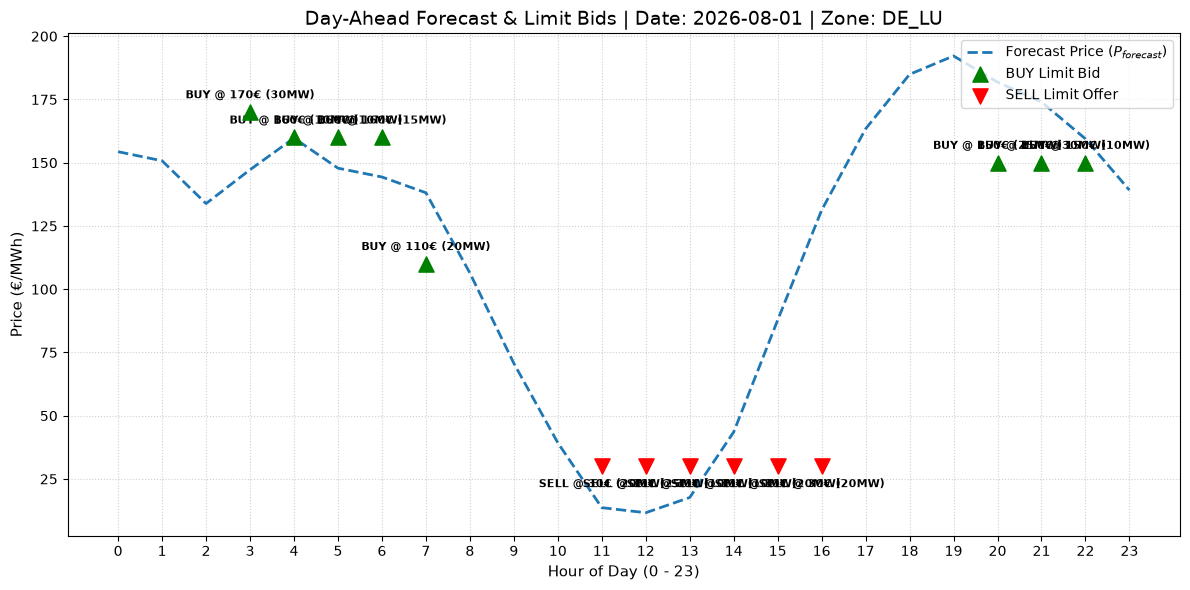


📊 DAY-AHEAD TRADING LEDGER (2026-08-01)


,hour,forecast_price_eur_mwh,price_eur_mwh,side,limit_price,volume_mw,Cleared,Cleared_MW,Position_Status,Cashflow_€
0,0,154.359104,156.9950,-,-,-,NO BID,0.0,FLAT,0.0000
1,1,150.763738,154.6075,-,-,-,NO BID,0.0,FLAT,0.0000
2,2,133.858902,154.5225,-,-,-,NO BID,0.0,FLAT,0.0000
3,3,147.235264,155.5175,BUY,170.0,30.0,CLEARED,30.0,LONG,-4665.5250
4,4,159.738384,154.7900,BUY,160.0,10.0,CLEARED,10.0,LONG,-1547.9000
5,5,147.855296,146.4225,BUY,160.0,10.0,CLEARED,10.0,LONG,-1464.2250
6,6,144.365745,140.4075,BUY,160.0,15.0,CLEARED,15.0,LONG,-2106.1125
7,7,138.126550,123.2725,BUY,110.0,20.0,REJECTED,0.0,FLAT,0.0000
8,8,106.394317,100.9225,-,-,-,NO BID,0.0,FLAT,0.0000
9,9,70.709724,57.1525,-,-,-,NO BID,0.0,FLAT,0.0000


--------------------------------------------------
📈 SUMMARY METRICS DASHBOARD
--------------------------------------------------
Total Submitted Bids : 14
Cleared Bids         : 7
Order Clearance Rate : 50.00%
-------------------Long Position Details/Electricity to Sell tomorrow-------------------------------
   hour  Cleared_MW  price_eur_mwh
3     3        30.0       155.5175
4     4        10.0       154.7900
5     5        10.0       146.4225
6     6        15.0       140.4075
-------------------Short Position Details/Electricity to Buy tomorrow-------------------------------
    hour  Cleared_MW  price_eur_mwh
14    14       -10.0        45.5175
15    15       -20.0       107.5650
16    16       -20.0       145.1350
Net Cashflow         : €-4,274.59
--------------------------------------------------


In [81]:
TARGET_DATE = "2026-08-01"
TARGET_ZONE = "DE_LU"
ledger_df,actual_day_ahead_price=run_day_ahead_pnl_analysis(BASE_DIR, TARGET_ZONE, TARGET_DATE)


In [82]:
### intraday price simulation
import numpy as np
def generate_modeled_intraday_prices(actual_da_df: pd.DataFrame, volatility_sigma: float = 5.0) -> pd.DataFrame:
    """
    Generates realistic synthetic Intraday prices using Day-Ahead prices 
    plus stochastic deviation (spread).
    """
    np.random.seed(42)  # For reproducible backtests
    intraday_df = actual_da_df.copy()
    
    # Simulate realistic intraday price spread around Day-Ahead price
    spread = np.random.normal(loc=0.0, scale=volatility_sigma, size=len(intraday_df))
    
    intraday_df['P_Intraday'] = np.round(intraday_df['price_eur_mwh'] + spread, 2)
    return intraday_df[['hour', 'P_Intraday']]

In [83]:


def settle_intraday_positions(ledger_df: pd.DataFrame, intraday_df: pd.DataFrame) -> pd.DataFrame:
    """
    Settles open Day-Ahead positions in the Intraday market.
    
    Parameters:
    - ledger_df: Your existing 24-hour ledger containing 'Cleared_MW' and 'Cashflow_€' (DA Cashflow)
    - intraday_df: DataFrame with columns ['hour', 'P_Intraday']
    """
    # Merge Intraday prices into ledger
    settled_df = ledger_df.merge(intraday_df[['hour', 'P_Intraday']], on='hour', how='left')
    
    # Calculate Intraday Action and Cashflow
    settled_df['ID_Action'] = settled_df['Cleared_MW'].apply(
        lambda x: 'SELL (Flatten LONG)' if x > 0 else ('BUY (Flatten SHORT)' if x < 0 else 'NO ACTION')
    )
    
    # Intraday Cashflow = -1 * Cleared_MW * P_Intraday
    # (If Cleared_MW > 0, we sell -> cash inflow +)
    # (If Cleared_MW < 0, we buy -> cash outflow -)
    settled_df['Cashflow_ID_€'] = 1.0 * settled_df['Cleared_MW'] * settled_df['P_Intraday']
    
    # Net PnL = DA Cashflow + Intraday Cashflow
    # Note: If your ledger DA cashflow column is named 'Cashflow_€', rename/use accordingly
    da_cashflow_col = 'Cashflow_€' if 'Cashflow_€' in settled_df.columns else 'PnL_DA'
    settled_df['Net_PnL_€'] = settled_df[da_cashflow_col] + settled_df['Cashflow_ID_€']
    
    # After Intraday trade, net physical position is 0 (FLAT)
    settled_df['Final_Position_MW'] = 0.0
    
    return settled_df

def print_intraday_summary(settled_df: pd.DataFrame):
    """Prints a clear financial summary of the Day-Ahead + Intraday cycle."""
    da_cashflow = settled_df['Cashflow_€'].sum() if 'Cashflow_€' in settled_df.columns else settled_df['PnL_DA'].sum()
    id_cashflow = settled_df['Cashflow_ID_€'].sum()
    total_pnl = settled_df['Net_PnL_€'].sum()
    
    print("\n" + "="*50)
    print("💰 INTRADAY SETTLEMENT & FINAL PnL DASHBOARD")
    print("="*50)
    # print(f"Total Day-Ahead Cashflow   : €{da_cashflow:+,.2f}")
    # print(f"Total Intraday Cashflow   : €{id_cashflow:+,.2f}")
    print(f"--------------------------------------------------")
    print(f"NET BACKTEST PnL          : €{total_pnl:+,.2f}")
    print(f"Final Open Position       : 0.00 MW (100% Flattened)")
    print("="*50 + "\n")

In [84]:
intraday_df = generate_modeled_intraday_prices(actual_day_ahead_price, volatility_sigma=5.0)
final_ledger = settle_intraday_positions(ledger_df, intraday_df)

# Display 24-hour settlement table
cols_to_show = ['hour', 'price_eur_mwh', 'P_Intraday', 'Cleared_MW', 'Cashflow_€', 'ID_Action', 'Cashflow_ID_€', 'Net_PnL_€']
display(final_ledger[cols_to_show])

# Print Summary
print_intraday_summary(final_ledger)

,hour,price_eur_mwh,P_Intraday,Cleared_MW,Cashflow_€,ID_Action,Cashflow_ID_€,Net_PnL_€
0,0,156.9950,159.48,0.0,0.0000,NO ACTION,0.0,0.0000
1,1,154.6075,153.92,0.0,0.0000,NO ACTION,0.0,0.0000
2,2,154.5225,157.76,0.0,0.0000,NO ACTION,0.0,0.0000
3,3,155.5175,163.13,30.0,-4665.5250,SELL (Flatten LONG),4893.9,228.3750
4,4,154.7900,153.62,10.0,-1547.9000,SELL (Flatten LONG),1536.2,-11.7000
5,5,146.4225,145.25,10.0,-1464.2250,SELL (Flatten LONG),1452.5,-11.7250
6,6,140.4075,148.30,15.0,-2106.1125,SELL (Flatten LONG),2224.5,118.3875
7,7,123.2725,127.11,0.0,0.0000,NO ACTION,0.0,0.0000
8,8,100.9225,98.58,0.0,0.0000,NO ACTION,0.0,0.0000
9,9,57.1525,59.87,0.0,0.0000,NO ACTION,0.0,0.0000



💰 INTRADAY SETTLEMENT & FINAL PnL DASHBOARD
--------------------------------------------------
NET BACKTEST PnL          : €+567.21
Final Open Position       : 0.00 MW (100% Flattened)

